## Load Olist Datasets

### Subtask:
Import the pandas library and read each Olist CSV file into a separate DataFrame with a descriptive variable name.


In [ ]:
import pandas as pd
import sqlite3
from pathlib import Path

geolocation_df = pd.read_csv('olist_geolocation_dataset.csv')
product_category_translation_df = pd.read_csv('product_category_name_translation.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
customers_df = pd.read_csv('olist_customers_dataset.csv')
order_reviews_df = pd.read_csv('olist_order_reviews_dataset.csv')
order_payments_df = pd.read_csv('olist_order_payments_dataset.csv')
sellers_df = pd.read_csv('olist_sellers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')

print("All Olist datasets loaded successfully into DataFrames.")

All Olist datasets loaded successfully into DataFrames.


In [ ]:
dataframes = {
    'geolocation_df': geolocation_df,
    'product_category_translation_df': product_category_translation_df,
    'order_items_df': order_items_df,
    'products_df': products_df,
    'customers_df': customers_df,
    'order_reviews_df': order_reviews_df,
    'order_payments_df': order_payments_df,
    'sellers_df': sellers_df,
    'orders_df': orders_df
}

def inspect_df(name, df):
    print(f"\n📊 TABLE: {name}")
    print("-" * 50)

    # Shape
    print(f"Shape: {df.shape}")

    # Columns & Types
    print("\nColumns & Data Types:")
    for col, dtype in df.dtypes.items():
        print(f"  - {col}: {dtype}")

    # Missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print("\nMissing Values:")
    if len(missing) == 0:
        print("  None")
    else:
        for col, val in missing.items():
            print(f"  - {col}: {val}")

    # Duplicates
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")

    print("-" * 50)


for name, df in dataframes.items():
    inspect_df(name, df)


📊 TABLE: geolocation_df
--------------------------------------------------
Shape: (1000163, 5)

Columns & Data Types:
  - geolocation_zip_code_prefix: int64
  - geolocation_lat: float64
  - geolocation_lng: float64
  - geolocation_city: object
  - geolocation_state: object

Missing Values:
  None

Duplicate Rows: 261831
--------------------------------------------------

📊 TABLE: product_category_translation_df
--------------------------------------------------
Shape: (71, 2)

Columns & Data Types:
  - product_category_name: object
  - product_category_name_english: object

Missing Values:
  None

Duplicate Rows: 0
--------------------------------------------------

📊 TABLE: order_items_df
--------------------------------------------------
Shape: (112650, 7)

Columns & Data Types:
  - order_id: object
  - order_item_id: int64
  - product_id: object
  - seller_id: object
  - shipping_limit_date: object
  - price: float64
  - freight_value: float64

Missing Values:
  None

Duplicate Row

# Convert date columns before sending data to SQL

In [ ]:
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        format='%d/%m/%Y %H:%M',
        errors='coerce'
    )

In [ ]:
orders_df[date_cols_orders].dtypes
order_items_df["shipping_limit_date"].dtype

dtype('O')

In [ ]:
orders_df['order_purchase_timestamp'].head()
orders_df['order_purchase_timestamp'].isna().sum()

np.int64(0)

In [ ]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(
    orders_df['order_purchase_timestamp'],
    errors='coerce'
)


In [ ]:
for col in date_cols_orders:
    print(col, orders_df[col].dtype)

order_purchase_timestamp datetime64[ns]
order_approved_at datetime64[ns]
order_delivered_carrier_date datetime64[ns]
order_delivered_customer_date datetime64[ns]
order_estimated_delivery_date datetime64[ns]


In [ ]:
orders_df['order_purchase_timestamp'].head(20)

,order_purchase_timestamp
0,2017-10-02 10:56:00
1,2018-07-24 20:41:00
2,2018-08-08 08:38:00
3,2017-11-18 19:28:00
4,2018-02-13 21:18:00
5,2017-07-09 21:57:00
6,2017-04-11 12:22:00
7,2017-05-16 13:10:00
8,2017-01-23 18:29:00
9,2017-07-29 11:55:00


# Create a SQLite database

In [ ]:
conn = sqlite3.connect("ecommerce_analysis.db")

# Push pandas DataFrames into SQLite tables

In [ ]:
orders_df.to_sql("orders", conn, if_exists="replace", index=False)
order_items_df.to_sql("order_items", conn, if_exists= "replace", index = False)
order_payments_df.to_sql("order_payments", conn, if_exists="replace", index=False)
customers_df.to_sql("customers", conn, if_exists="replace", index=False)
products_df.to_sql("products", conn, if_exists="replace" , index=False)
product_category_translation_df.to_sql("category_translation", conn, if_exists="replace", index=False)
geolocation_df.to_sql("geolocation", conn, if_exists="replace", index=False)

1000163

# reusable SQL query function

In [ ]:
def run_query(query, conn=conn):
    return pd.read_sql_query(query, conn)

In [ ]:
run_query("SELECT COUNT(*) AS row_count FROM orders;")
run_query("SELECT COUNT(*) AS row_count FROM order_items;")
run_query("SELECT COUNT(*) AS row_count FROM order_payments;")
run_query("SELECT COUNT(*) AS row_count FROM customers;")
run_query("SELECT COUNT(*) AS row_count FROM products;")
run_query("SELECT COUNT(*) AS row_count FROM category_translation;")

,row_count
0,71


# Running sql magic

In [ ]:
!pip install ipython-sql

In [ ]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
%sql sqlite:///ecommerce_analysis.db

**First SQL test query: order status distribution**

In [ ]:
!pip install prettytable==3.7.0

In [ ]:
%%sql
SELECT
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;

 * sqlite:///ecommerce_analysis.db
Done.


order_status,order_count
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
%%sql
SELECT COUNT(DISTINCT order_id) AS delivered_orders
FROM orders
WHERE order_status = 'delivered';

 * sqlite:///ecommerce_analysis.db
Done.


delivered_orders
96478


KPI 1

In [ ]:
%sql SELECT STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month, \
ROUND(SUM(op.payment_value), 2) AS monthly_revenue \
FROM orders o \
JOIN order_payments op ON o.order_id = op.order_id \
WHERE o.order_status = 'delivered' \
GROUP BY month \
ORDER BY month;

 * sqlite:///ecommerce_analysis.db
Done.


month,monthly_revenue
2016-10,46566.71
2016-12,19.62
2017-01,127545.67
2017-02,271298.65
2017-03,414369.39
2017-04,390952.18
2017-05,567066.73
2017-06,490225.6
2017-07,566403.93
2017-08,646000.61


In [ ]:
result = %sql SELECT STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month, \
ROUND(SUM(op.payment_value), 2) AS monthly_revenue \
FROM orders o \
JOIN order_payments op ON o.order_id = op.order_id \
WHERE o.order_status = 'delivered' \
GROUP BY month \
ORDER BY month;
dfm = result.DataFrame()

 * sqlite:///ecommerce_analysis.db
Done.


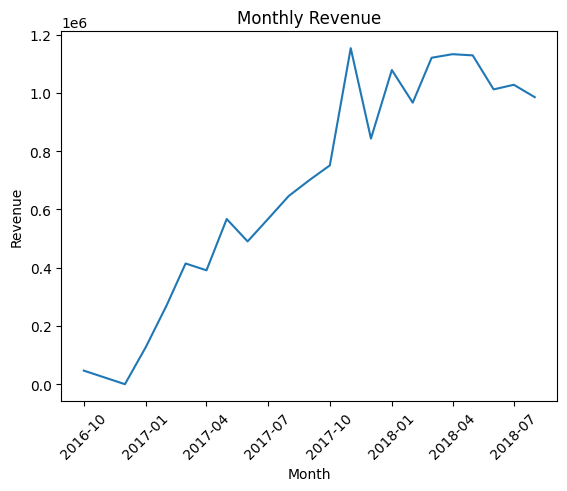

In [ ]:
import matplotlib.pyplot as plt

dfm['month'] = pd.to_datetime(dfm['month'])

plt.figure()
plt.plot(dfm['month'], dfm['monthly_revenue'])

plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

KPI 2

In [ ]:
%%sql
SELECT
    STRFTIME('%Y-%m', order_purchase_timestamp) AS month,
    COUNT(*)
FROM orders
GROUP BY month
;

 * sqlite:///ecommerce_analysis.db
Done.


month,COUNT(*)
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245
2017-07,4026


KPI3

Distinct customers

In [ ]:
%%sql
SELECT
    COUNT(DISTINCT c.customer_unique_id) AS active_customers
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';

 * sqlite:///ecommerce_analysis.db
Done.


active_customers
93358


total orders

In [ ]:
%%sql
SELECT
    COUNT( * ) AS Number_of_orders
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';

 * sqlite:///ecommerce_analysis.db
Done.


Number_of_orders
96478


repeat costumers

In [ ]:
%%sql
SELECT COUNT(*) AS repeat_customers
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS delivered_orders
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    HAVING COUNT(o.order_id) > 1
);

 * sqlite:///ecommerce_analysis.db
Done.


repeat_customers
2801


customer retention

In [ ]:
%%sql
SELECT
    COUNT(CASE WHEN delivered_orders > 1 THEN 1 END) * 100.0 / COUNT(*) AS repeat_customer_rate
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS delivered_orders
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
);

 * sqlite:///ecommerce_analysis.db
Done.


repeat_customer_rate
3.0002784978255748


# Average Order Value (AOV)

In [ ]:
%%sql
SELECT
    order_id,
    COUNT(*) AS payment_rows
FROM order_payments
GROUP BY order_id
HAVING COUNT(*) > 1
ORDER BY payment_rows DESC;

 * sqlite:///ecommerce_analysis.db
Done.


order_id,payment_rows
fa65dad1b0e818e3ccc5cb0e39231352,29
ccf804e764ed5650cd8759557269dc13,26
285c2e15bebd4ac83635ccc563dc71f4,22
895ab968e7bb0d5659d16cd74cd1650c,21
fedcd9f7ccdc8cba3a18defedd1a5547,19
ee9ca989fc93ba09a6eddc250ce01742,19
4bfcba9e084f46c8e3cb49b0fa6e6159,15
21577126c19bf11a0b91592e5844ba78,15
4689b1816de42507a7d63a4617383c59,14
3c58bffb70dcf45f12bdf66a3c215905,14


In [ ]:
%%sql
SELECT
    ROUND(SUM(op.payment_value) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM order_payments op
JOIN orders o
    ON op.order_id = o.order_id
WHERE o.order_status = 'delivered';

 * sqlite:///ecommerce_analysis.db
Done.


avg_order_value
159.86


In [ ]:
query_kpi_summary = """
SELECT
    ROUND(SUM(op.payment_value), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT c.customer_unique_id) AS active_customers,
    ROUND(SUM(op.payment_value) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

kpi_summary_df = run_query(query_kpi_summary)
kpi_summary_df

,total_revenue,total_orders,active_customers,avg_order_value
0,15422461.77,96477,93357,159.86


In [ ]:
query_monthly_trends = """
SELECT
    STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(op.payment_value), 2) AS revenue,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(op.payment_value) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month ;
"""

monthly_trends_df = run_query(query_monthly_trends)
monthly_trends_df

,month,revenue,orders,avg_order_value
0,2016-10,46566.71,265,175.72
1,2016-12,19.62,1,19.62
2,2017-01,127545.67,750,170.06
3,2017-02,271298.65,1653,164.13
4,2017-03,414369.39,2546,162.75
5,2017-04,390952.18,2303,169.76
6,2017-05,567066.73,3546,159.92
7,2017-06,490225.60,3135,156.37
8,2017-07,566403.93,3872,146.28
9,2017-08,646000.61,4193,154.07


<Axes: title={'center': 'avg_order_value'}, xlabel='month'>

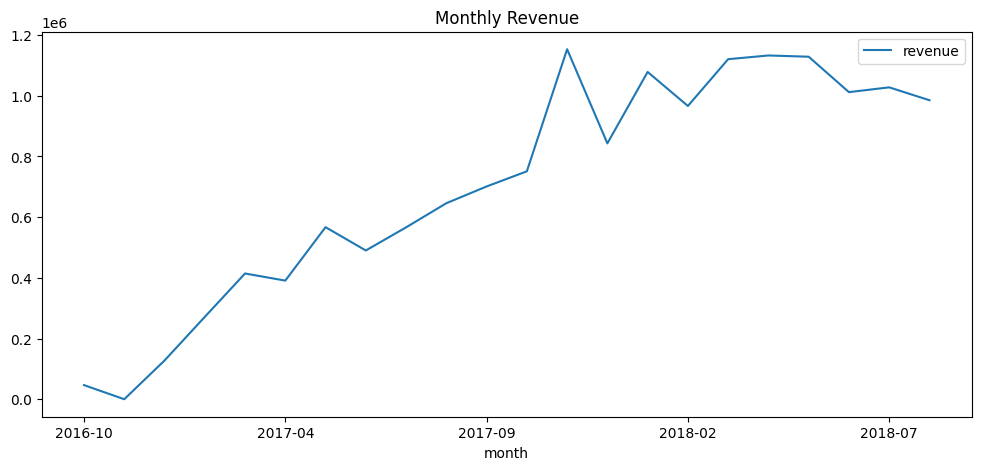

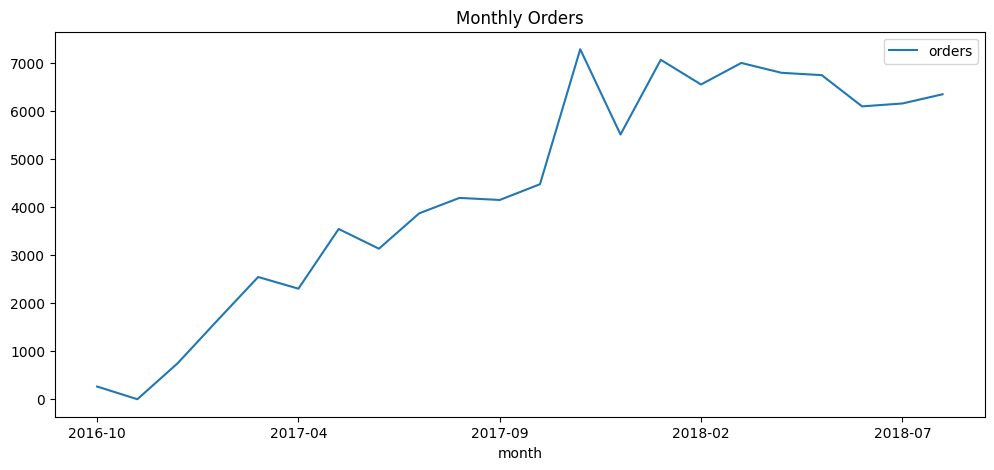

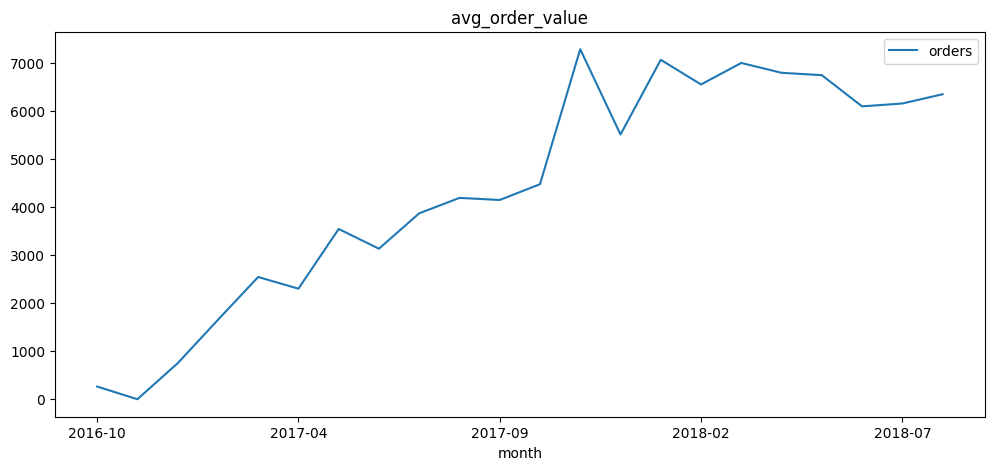

In [ ]:
monthly_trends_df.plot(x='month', y='revenue', figsize=(12,5), title='Monthly Revenue')
monthly_trends_df.plot(x='month', y='orders', figsize=(12,5), title='Monthly Orders')
monthly_trends_df.plot(x='month', y='orders', figsize=(12,5), title='avg_order_value')

# Category Revenue

In [ ]:
query_category_performance = """
SELECT
    COALESCE(ct.product_category_name_english, 'Unknown') AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(*) AS total_items_sold
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN category_translation ct
    ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 20;
"""

category_df = run_query(query_category_performance)
category_df

,category,total_revenue,total_items_sold
0,health_beauty,1233131.72,9465
1,watches_gifts,1166176.98,5859
2,bed_bath_table,1023434.76,10953
3,sports_leisure,954852.55,8431
4,computers_accessories,888724.61,7644
5,furniture_decor,711927.69,8160
6,housewares,615628.69,6795
7,cool_stuff,610204.10,3718
8,auto,578966.65,4140
9,toys,471286.48,4030


In [ ]:
query_order_categories = """
SELECT DISTINCT
    o.order_id,
    COALESCE(ct.product_category_name_english, 'Unknown') AS category
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN category_translation ct
    ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered';
"""

order_categories_df = run_query(query_order_categories)
order_categories_df.head()

,order_id,category
0,e481f51cbdc54678b7cc49136f2d6af7,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,stationery


In [ ]:
categories_per_order = (
    order_categories_df.groupby('order_id')['category']
    .nunique()
    .reset_index(name='num_categories')
)

categories_per_order['num_categories'].describe()

,num_categories
count,96478.000000
mean,1.008271
std,0.092607
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


In [ ]:
categories_per_order['num_categories'].value_counts().sort_index()

,count
num_categories,
1,95698
2,762
3,18


In [ ]:
basket = (
    order_categories_df.assign(value=1)
    .pivot_table(
        index='order_id',
        columns='category',
        values='value',
        aggfunc='max',
        fill_value=0
    )
)

In [ ]:
category_support = basket.mean().sort_values(ascending=False)
category_support.head(10)

,0
category,
bed_bath_table,0.096105
health_beauty,0.089627
sports_leisure,0.078049
computers_accessories,0.067684
furniture_decor,0.065372
housewares,0.059527
watches_gifts,0.056956
telephony,0.042424
auto,0.039491


In [ ]:
!pip install mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
frequent_itemsets = apriori(
    basket.astype(bool),
    min_support=0.0001,
    use_colnames=True
)

frequent_itemsets.sort_values('support', ascending=False).head(10)

,support,itemsets
8,0.096105,(bed_bath_table)
43,0.089627,(health_beauty)
64,0.078049,(sports_leisure)
16,0.067684,(computers_accessories)
39,0.065372,(furniture_decor)
49,0.059527,(housewares)
69,0.056956,(watches_gifts)
67,0.042424,(telephony)
6,0.039491,(auto)
68,0.039429,(toys)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(bed_bath_table),(home_confort),0.000446,0.004638,1.141398
1,(home_confort),(bed_bath_table),0.000446,0.109694,1.141398


In [ ]:
rules_clean = rules.copy()

rules_clean['antecedents'] = rules_clean['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_clean['consequents'] = rules_clean['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

rules_clean = rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_clean = rules_clean.sort_values(by='lift', ascending=False)

rules_clean.head(15)

,antecedents,consequents,support,confidence,lift
0,bed_bath_table,home_confort,0.000446,0.004638,1.141398
1,home_confort,bed_bath_table,0.000446,0.109694,1.141398


In [ ]:
print(rules_clean.head(15).to_string(index=False))

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


# Average Delivery Time

In [ ]:
query_delivery_time = """
SELECT
    ROUND(AVG(
        JULIANDAY(order_delivered_customer_date) -
        JULIANDAY(order_purchase_timestamp)
    ), 2) AS avg_delivery_days
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL;
"""

run_query(query_delivery_time)

,avg_delivery_days
0,12.56


In [ ]:
query_delivery_delay = """
SELECT
    ROUND(AVG(
        JULIANDAY(order_delivered_customer_date) -
        JULIANDAY(order_estimated_delivery_date)
    ), 2) AS avg_delay_days
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL;
"""

run_query(query_delivery_delay)

,avg_delay_days
0,-11.18


In [ ]:
query_seller_delay = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) -
        JULIANDAY(o.order_estimated_delivery_date)
    ), 2) AS avg_delay_days
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY oi.seller_id
HAVING total_orders >= 10
ORDER BY avg_delay_days DESC
LIMIT 10;
"""

seller_delay_df = run_query(query_seller_delay)
seller_delay_df

,seller_id,total_orders,avg_delay_days
0,cb41bfbcbda0aea354a834ab222f9a59,11,10.30
1,b1b3948701c5c72445495bd161b83a4c,14,4.74
2,2a1348e9addc1af5aaa619b1a3679d6b,48,1.35
3,26e2c91ef821e1ff8985f408788fe35b,12,0.06
4,5f67c6082caacb26e431a7b17940cece,13,-1.12
5,054694fa03fe82cec4b7551487331d74,20,-1.37
6,54965bbe3e4f07ae045b90b0b8541f52,73,-1.69
7,4e5725ba188db8252977a4f0227bd462,21,-2.01
8,ca4b77513ac2040591b0d8fae6958380,14,-2.38
9,0417b067eeab773d2f7061a726dc477f,13,-3.19


<Axes: title={'center': 'Worst Performing Sellers by Delivery Delay'}, xlabel='seller_id'>

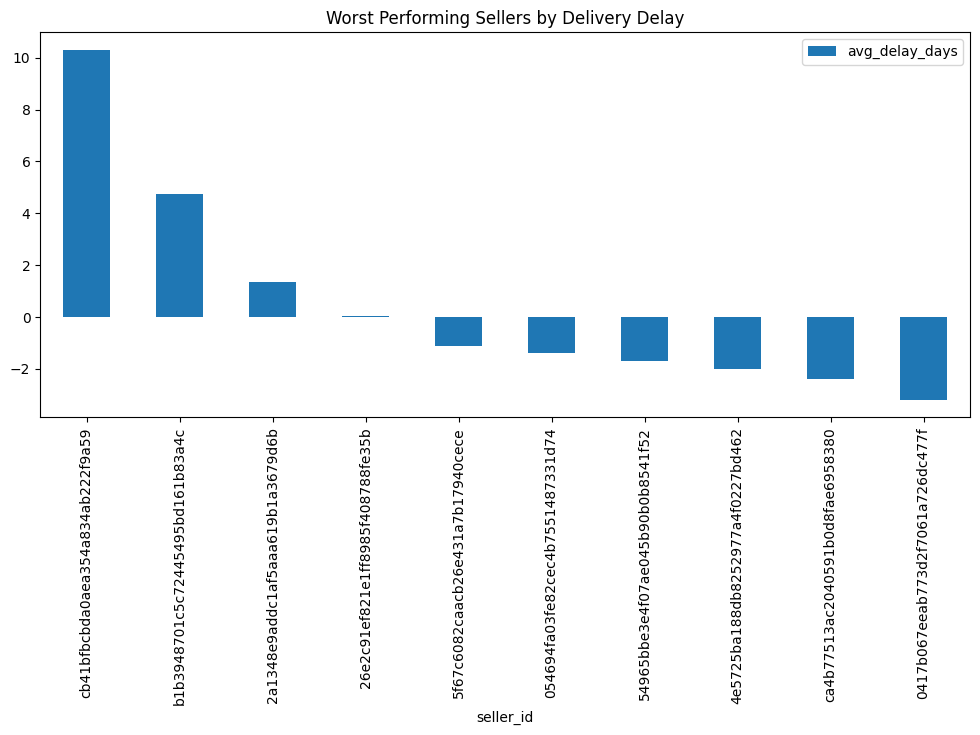

In [ ]:
seller_delay_df.plot(
    x='seller_id',
    y='avg_delay_days',
    kind='bar',
    figsize=(12,5),
    title='Worst Performing Sellers by Delivery Delay'
)